# Close Is Not the Same as Walkable

**Author:** Jennifer Zhang  
**Mapping Systems — Assignment 03: Networks**

## Research statement

**How much longer is the shortest route on a real pedestrian network than the straight-line distance among four public study-day destinations around Columbia University, and which pair is most distorted by the street-and-path network?**

I chose a transit entrance, a studio/class building, a library, and a park entrance because they represent distinct public activities while remaining close enough that straight-line proximity can feel persuasive. Measuring all six unique pairs avoids designing the conclusion around one favored trip. Their coordinates were manually authored from public map inspection at entrance/place-reference precision, not exported from private location history.

## 1. Define the network

The network is an **undirected pedestrian graph** derived from OpenStreetMap walking data:

- **Nodes** are mapped intersections, path junctions, and endpoints.
- **Edges** are mapped walkable streets, footways, paths, and steps.
- **Edge weight** is the OSMnx `length` field in metres.
- **Route cost** is the sum of edge lengths, plus the two point-to-node snap connectors.

The original graph was created with OSMnx 2.1.0 using `network_type="walk"`. `prepare_network_snapshot.py` then clipped it to a documented Morningside Heights bounding box and retained the largest connected component. The clipped GraphML and its SHA-256 manifest are committed, so this notebook does not silently change when OpenStreetMap changes or when an API is unavailable.

This is a real mapped network, not a hand-drawn street grid. It still remains a model: an edge means a mapped walkable connection, not a guarantee about current conditions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

from network_analysis import (
    ANALYSIS_CRS,
    OUTPUT_DIR,
    build_interactive_map,
    calculate_all_pairs,
    graph_to_gdfs,
    load_inputs,
    plot_detour_ratio,
    plot_distance_comparison,
    plot_distance_scatter,
    plot_euclidean_connections,
    plot_network_definition,
    plot_selected_comparisons,
    plot_shortest_routes,
    plot_snap_validation,
    snap_locations,
    write_outputs,
)

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"font.size": 10, "axes.titlesize": 14})

In [2]:
graph, places, manifest = load_inputs()

network_summary = pd.Series(
    {
        "graph_type": type(graph).__name__,
        "network_type": manifest["network_type"],
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "connected_components": manifest["connected_components"],
        "crs": manifest["crs"],
        "source_created_with": manifest["source"]["source_created_with"],
        "source_created_date": manifest["source"]["source_created_date"],
        "snapshot_sha256": manifest["artifact_sha256"],
    },
    name="value",
)
display(network_summary.to_frame())

print("Snapshot build sequence:")
print("1. Request OpenStreetMap walking topology with OSMnx.")
print("2. Clip nodes by the documented WGS84 bounding box.")
print("3. Retain the largest connected component.")
print("4. Save GraphML and verify its SHA-256 checksum on every run.")

Snapshot build sequence:
1. Request OpenStreetMap walking topology with OSMnx.
2. Clip nodes by the documented WGS84 bounding box.
3. Retain the largest connected component.
4. Save GraphML and verify its SHA-256 checksum on every run.


,value
graph_type,MultiGraph
network_type,walk
nodes,2431
edges,3856
connected_components,1
crs,epsg:4326
source_created_with,OSMnx 2.1.0
source_created_date,2026-07-27 03:09:47
snapshot_sha256,79a0d3b2da417b40011061f0a882b055bf9aa321e4bef1...


### Convert graph topology into geographic layers

NetworkX stores topology; GeoPandas makes the same nodes and edges visible as geographic features. I preserve OSM `name` and `highway` tags and convert the edge `length` attribute to numeric metres before routing.

,name,highway,length_m
0,,footway,71.5 m
1,,footway,20.1 m
2,,footway,27.0 m
3,,footway,13.6 m
4,,footway,60.5 m
5,,footway,52.5 m
6,,"['footway', 'steps']",4.1 m
7,Saint Nicholas Avenue,secondary,67.7 m
8,Saint Nicholas Avenue,secondary,10.8 m
9,,footway,13.5 m


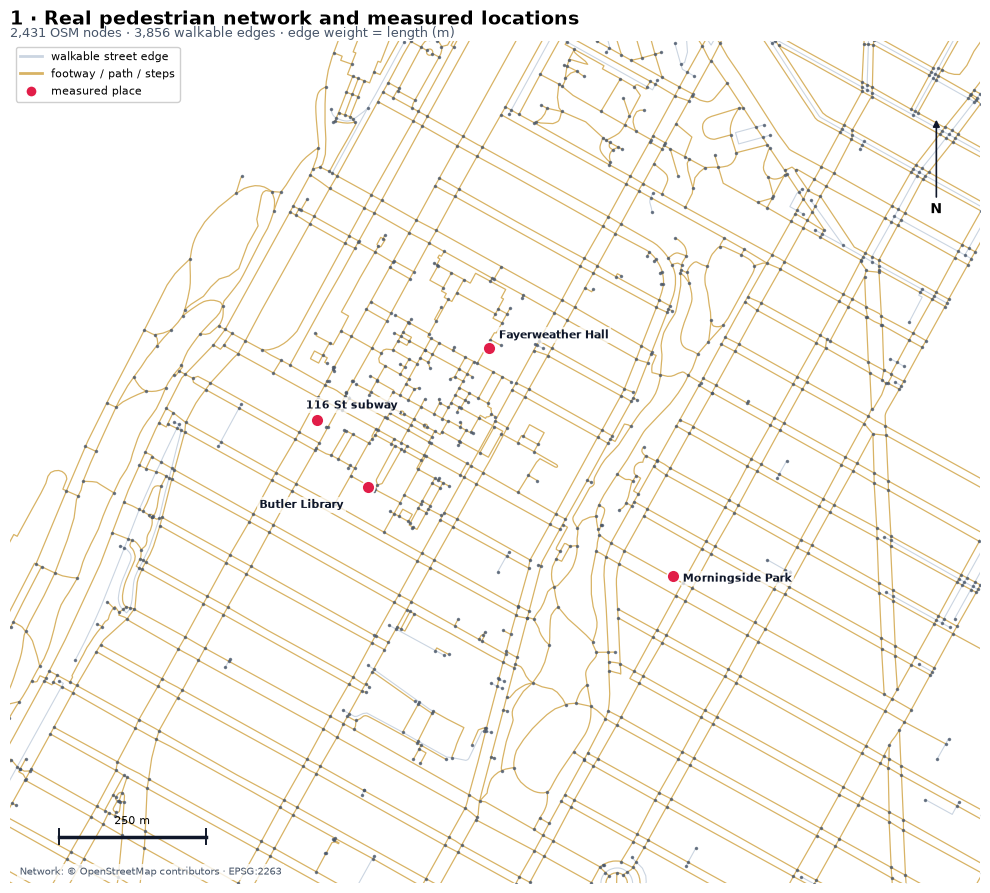

In [3]:
nodes, edges = graph_to_gdfs(graph)

display(
    edges[["name", "highway", "length_m"]]
    .replace("", pd.NA)
    .dropna(how="all")
    .head(10)
    .style.format({"length_m": "{:.1f} m"})
)

network_figure = plot_network_definition(edges, nodes, places)
plt.show()

## 2. Define the measured objects and graph nodes

The input coordinates describe the four public places. Shortest-path algorithms can only start and end at graph nodes, so each point is snapped in **NAD83 / New York Long Island (`EPSG:2263`)** to the nearest node. This projected CRS gives local metric-compatible distances after converting US survey feet to metres.

I retain the original points and record each connector. A route total therefore cannot become artificially short just because its point was moved onto the graph for free.

,place_id,short_name,role,snapped_node,connector_m
0,place-01,116 St subway,transit,3271250939,20.1 m
1,place-02,Fayerweather Hall,studio / class,2340960673,14.4 m
2,place-03,Butler Library,study,3907629298,12.7 m
3,place-04,Morningside Park,outdoor break,6814306897,19.9 m


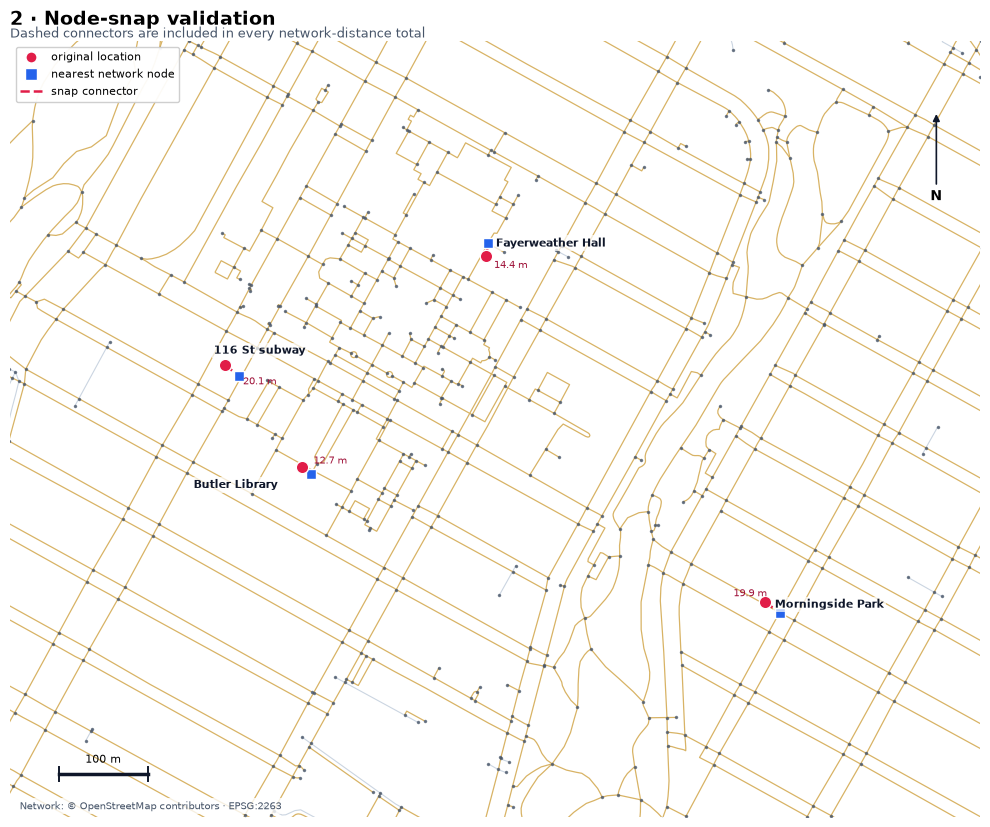

In [4]:
snapped, snap_connectors = snap_locations(graph, places, nodes)

node_table = snapped[
    ["place_id", "short_name", "role", "snapped_node", "connector_m"]
].copy()
display(node_table.style.format({"connector_m": "{:.1f} m"}))

snap_figure = plot_snap_validation(edges, nodes, snapped, snap_connectors)
plt.show()

## 3. Calculate two distances for every pair

There are four places, so there are `4 choose 2 = 6` unique pairs.

**Euclidean distance** is the length of a straight projected line between the two original coordinates:

`euclidean = distance(original A, original B)`

**Network distance** follows the shortest connected pedestrian path, weighted by mapped edge length:

`network = connector A + shortest_path(edge lengths) + connector B`

The **detour ratio** is `network / euclidean`. A value of 1.00 would mean that the network is no longer than the direct line; higher values show how much topology stretches apparent proximity.

In [5]:
results, routes, euclidean_links = calculate_all_pairs(graph, snapped)

display(
    results[
        [
            "pair_id",
            "pair_label",
            "euclidean_m",
            "origin_connector_m",
            "graph_path_m",
            "destination_connector_m",
            "network_m",
            "extra_m",
            "detour_ratio",
            "path_nodes",
        ]
    ].style.format(
        {
            "euclidean_m": "{:.1f}",
            "origin_connector_m": "{:.1f}",
            "graph_path_m": "{:.1f}",
            "destination_connector_m": "{:.1f}",
            "network_m": "{:.1f}",
            "extra_m": "+{:.1f}",
            "detour_ratio": "{:.2f}×",
        }
    )
)

,pair_id,pair_label,euclidean_m,origin_connector_m,graph_path_m,destination_connector_m,network_m,extra_m,detour_ratio,path_nodes
0,P1,116 St subway ↔ Fayerweather Hall,316.0,20.1,427.8,14.4,462.3,+146.3,1.46×,20
1,P2,116 St subway ↔ Butler Library,143.1,20.1,184.6,12.7,217.5,+74.4,1.52×,11
2,P3,116 St subway ↔ Morningside Park,659.1,20.1,838.8,19.9,878.8,+219.7,1.33×,27
3,P4,Fayerweather Hall ↔ Butler Library,312.8,14.4,387.9,12.7,415.1,+102.3,1.33×,22
4,P5,Fayerweather Hall ↔ Morningside Park,496.3,14.4,868.6,19.9,902.9,+406.6,1.82×,33
5,P6,Butler Library ↔ Morningside Park,538.9,12.7,768.2,19.9,800.8,+262.0,1.49×,24


## 4. Map what Euclidean distance assumes

The dashed lines below pass through blocks, buildings, walls, landscape, and any other obstruction. They are useful baselines precisely because they do **not** claim to be walkable routes.

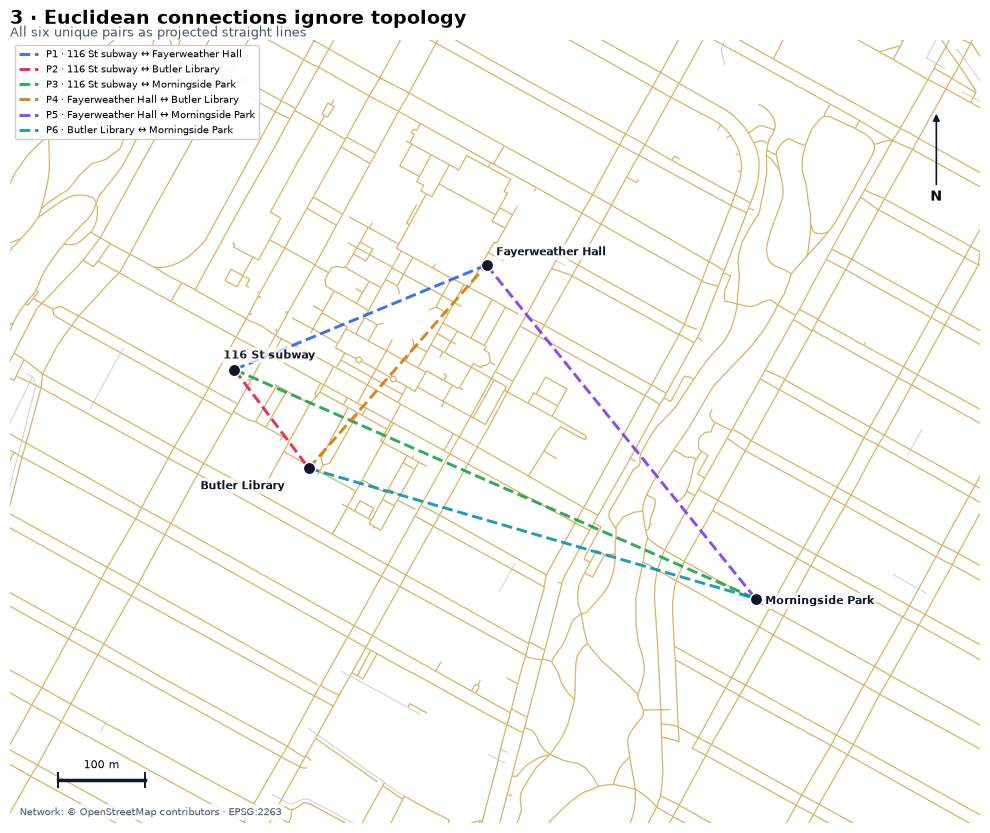

In [6]:
euclidean_figure = plot_euclidean_connections(edges, snapped, euclidean_links)
plt.show()

## 5. Map the shortest connected walks

NetworkX applies Dijkstra's length-weighted shortest-path algorithm to the OSM graph. The six colored routes bend along mapped streets, campus paths, entrances, and park-edge connections. Their geometry includes the two validated snap connectors.

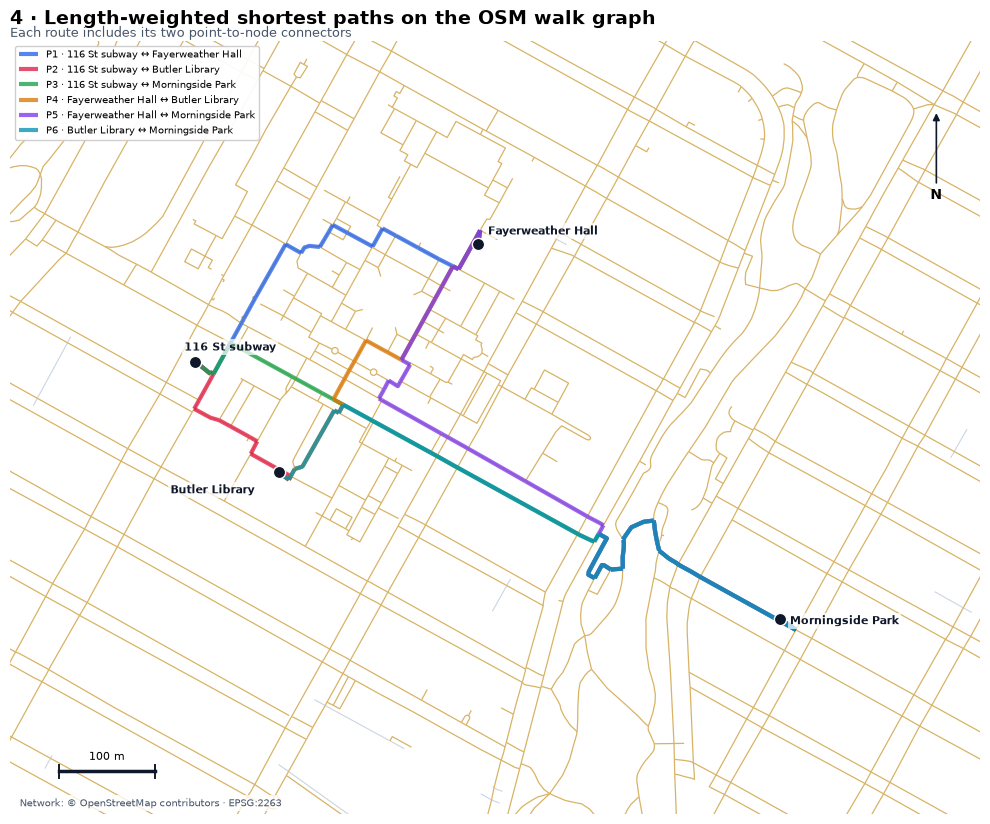

In [7]:
routes_figure = plot_shortest_routes(edges, snapped, routes)
plt.show()

## 6. Compare the least and most distorted pairs

The two small multiples use identical encodings: red dashes for the direct line and blue for the shortest mapped walk. Selecting the maximum and minimum ratios from the results—rather than choosing by eye—shows why detour is not simply a function of total distance.

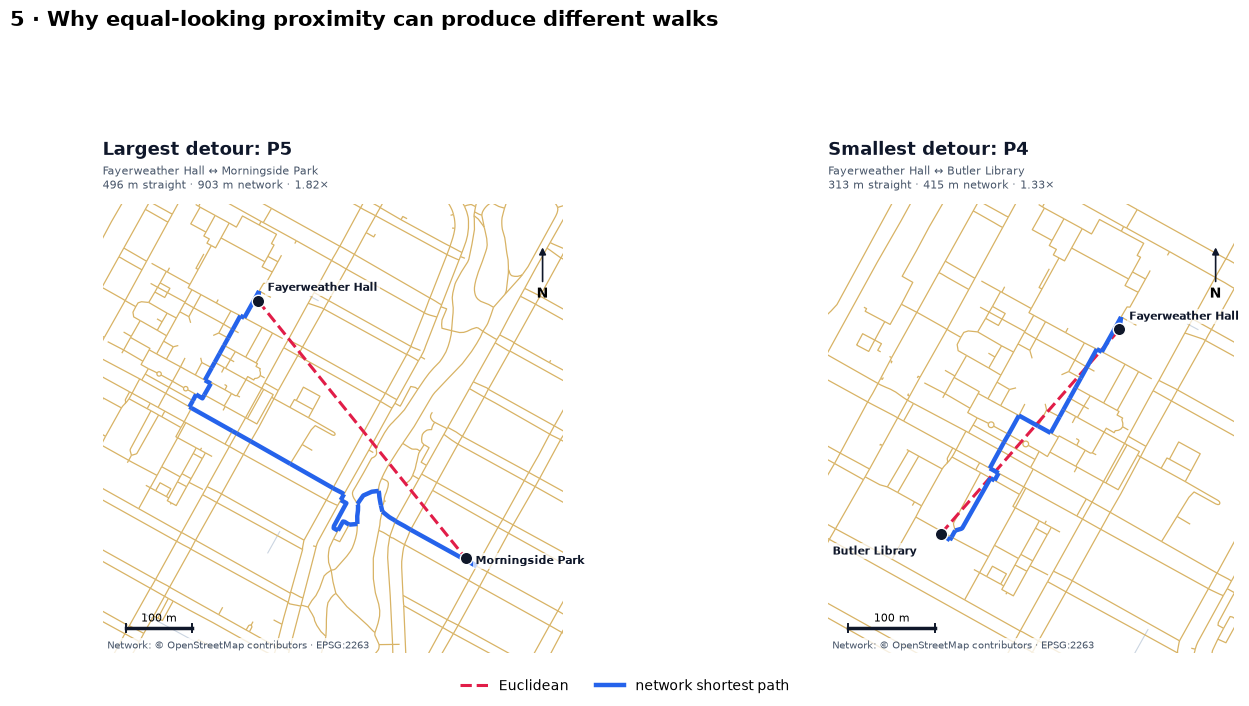

In [8]:
selected_figure = plot_selected_comparisons(
    edges, snapped, routes, euclidean_links, results
)
plt.show()

## 7. Compare the distances as charts

The first chart preserves metres, so it answers "how much farther?" The next two normalize or compare the measurements, answering "how distorted?" A long trip can add more metres while having a modest ratio; a shorter-looking trip can have the stronger topological penalty.

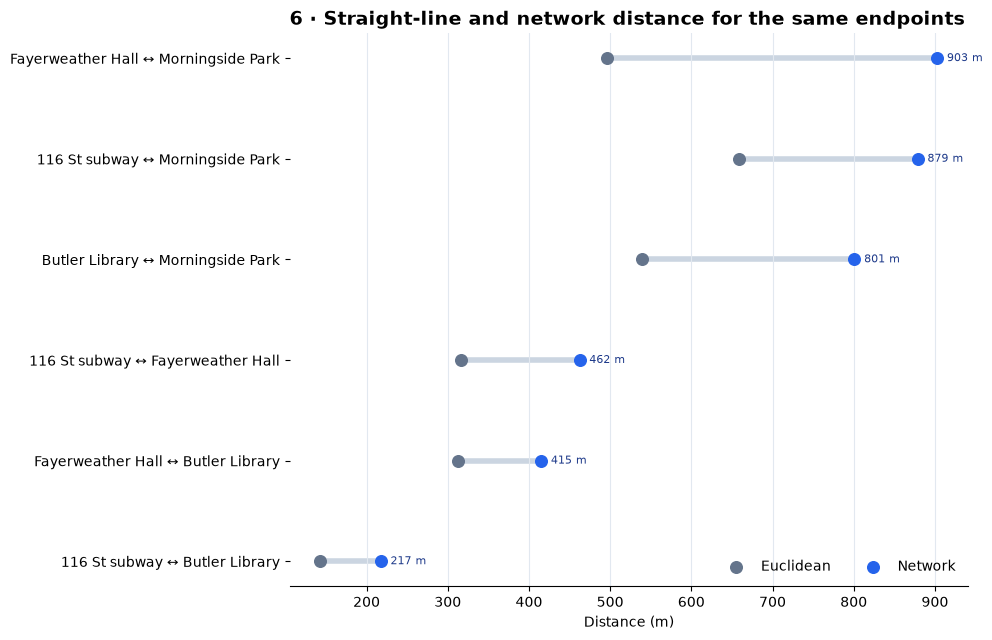

In [9]:
distance_figure = plot_distance_comparison(results)
plt.show()

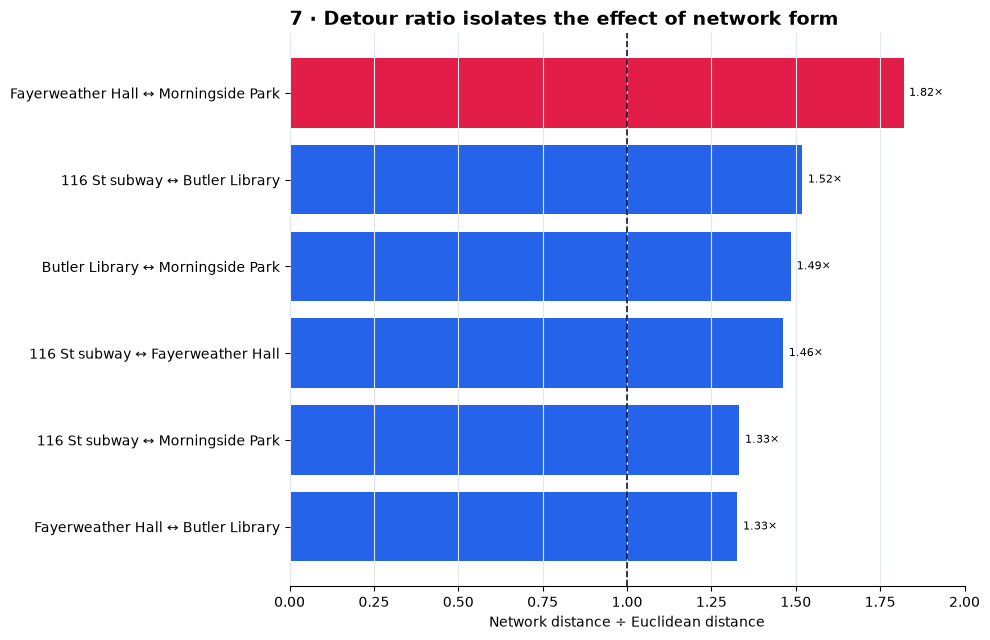

In [10]:
ratio_figure = plot_detour_ratio(results)
plt.show()

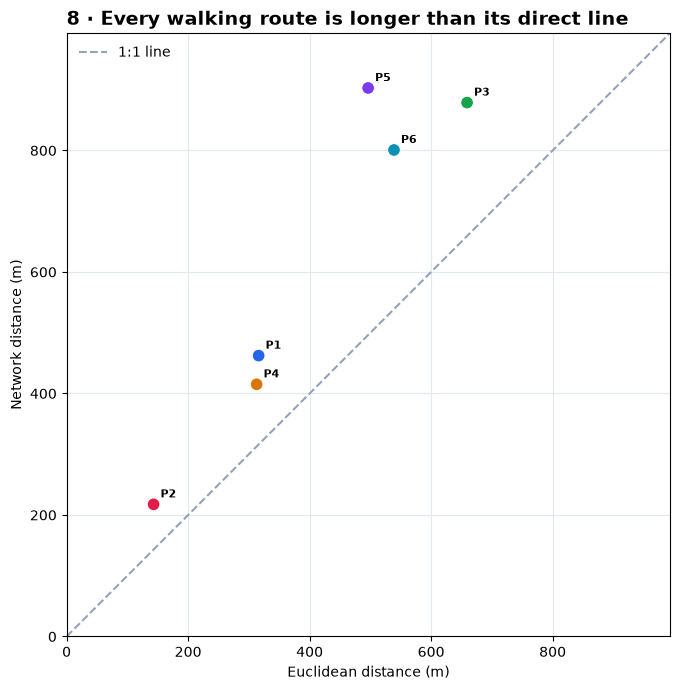

In [11]:
scatter_figure = plot_distance_scatter(results)
plt.show()

## 8. Results and experiential reflection

The code below derives every quoted number from the final connector-inclusive table, preventing the written reflection from drifting away from the analysis.

In [12]:
largest = results.loc[results["detour_ratio"].idxmax()]
smallest = results.loc[results["detour_ratio"].idxmin()]
largest_extra = results.loc[results["extra_m"].idxmax()]

display(
    Markdown(
        f'''
### What the numbers show

- **Largest proportional detour:** {largest['pair_id']} ({largest['pair_label']}) is **{largest['network_m']:.0f} m** on the network versus **{largest['euclidean_m']:.0f} m** straight-line, a **{largest['detour_ratio']:.2f}×** ratio and **{largest['extra_m']:.0f} added metres**.
- **Smallest proportional detour:** {smallest['pair_id']} ({smallest['pair_label']}) is **{smallest['detour_ratio']:.2f}×** its direct line.
- **Largest absolute addition:** {largest_extra['pair_id']} adds **{largest_extra['extra_m']:.0f} m** beyond Euclidean distance.
- Across all six pairs, the median detour ratio is **{results['detour_ratio'].median():.2f}×**.

### Experiential interpretation

Euclidean distance represents visual or cognitive closeness: two coordinates can look near because the line between them is short. Walking is sequential and constrained. I must reach a usable entrance, join a connected path, follow legal crossings, and sometimes move away from the destination before approaching it again. The largest ratio occurs between Fayerweather Hall and Morningside Park, where campus circulation and the park edge make the apparently diagonal connection much less direct. By contrast, pairs aligned with continuous corridors have lower ratios even when their walks are longer in absolute metres.

The network result is closer to a navigational experience than the Euclidean line, but it is **not the experience itself**. Its cost treats every metre as equal. A steep stair, a delayed crossing, a crowded campus passage, a closed gate, or an uncomfortable block can matter more than several flat metres.
'''
    )
)


### What the numbers show

- **Largest proportional detour:** P5 (Fayerweather Hall ↔ Morningside Park) is **903 m** on the network versus **496 m** straight-line, a **1.82×** ratio and **407 added metres**.
- **Smallest proportional detour:** P4 (Fayerweather Hall ↔ Butler Library) is **1.33×** its direct line.
- **Largest absolute addition:** P5 adds **407 m** beyond Euclidean distance.
- Across all six pairs, the median detour ratio is **1.47×**.

### Experiential interpretation

Euclidean distance represents visual or cognitive closeness: two coordinates can look near because the line between them is short. Walking is sequential and constrained. I must reach a usable entrance, join a connected path, follow legal crossings, and sometimes move away from the destination before approaching it again. The largest ratio occurs between Fayerweather Hall and Morningside Park, where campus circulation and the park edge make the apparently diagonal connection much less direct. By contrast, pairs aligned with continuous corridors have lower ratios even when their walks are longer in absolute metres.

The network result is closer to a navigational experience than the Euclidean line, but it is **not the experience itself**. Its cost treats every metre as equal. A steep stair, a delayed crossing, a crowded campus passage, a closed gate, or an uncomfortable block can matter more than several flat metres.


## 9. What this attribute can and cannot tell us

### It can tell us

- Whether all four locations are connected in the frozen OSM walking graph.
- The length-only shortest path between the **same original endpoints** used for the Euclidean baseline.
- How much mapped topology adds in metres and as a detour ratio.
- Whether snapping is small enough to be credible and whether all connector costs were included.
- Which pairs deserve closer field observation because apparent proximity and routed distance diverge.

### It cannot tell us

- Actual travel time: signals, crossing waits, entry delays, and walking speed are absent.
- Accessibility: stairs, curb cuts, elevators, slope, and surface quality are not fully modeled.
- Snap connectors are short straight point-to-node approximations; they are not independently verified entrance paths.
- Treating the graph as undirected can omit rare directional pedestrian-access restrictions encoded in the source.
- Current conditions: construction, temporary closures, weather, and opening hours can change.
- Personal comfort: crowds, lighting, noise, safety perception, and familiarity are not edge weights.
- A single "best" route: minimizing length can differ from minimizing time, effort, risk, or stress.

The locations are public-place reference coordinates, not a private GPS history. OpenStreetMap is a volunteered dataset; completeness and tags should be field-checked before using this analysis for navigation or accessibility claims.

## 10. Export, validate, and open the interactive map

The notebook exports machine-readable nodes, edges, snap connectors, Euclidean links, shortest routes, results, and an audit. It also creates an interactive Leaflet preview with selectable route layers on a live OpenStreetMap tile basemap. The interactive HTML supports inspection; the executed notebook is the assignment submission.

In [13]:
audit = write_outputs(
    manifest,
    nodes,
    edges,
    snapped,
    snap_connectors,
    results,
    routes,
    euclidean_links,
)
display(pd.Series(audit, name="value").to_frame())

required = [
    "distance_results.csv",
    "shortest_walking_routes.geojson",
    "node_snap_connectors.geojson",
    "network_audit.json",
    "09_interactive_routes.html",
]
for name in required:
    path = OUTPUT_DIR / name
    assert path.exists() and path.stat().st_size > 0, f"Missing output: {path}"

display(
    HTML(
        '<p><a href="outputs/09_interactive_routes.html" target="_blank">'
        'Open the interactive OpenStreetMap route preview ↗</a></p>'
    )
)
print("All six pairs are reachable, all eight figures exist, and all validation checks passed.")

All six pairs are reachable, all eight figures exist, and all validation checks passed.


,value
graph_snapshot_sha256,79a0d3b2da417b40011061f0a882b055bf9aa321e4bef1...
graph_nodes,2431
graph_edges,3856
network_type,walk
measured_places,4
unique_pairs_expected,6
unique_pairs_calculated,6
reachable_pairs,6
maximum_snap_connector_m,20.138522
network_not_shorter_than_euclidean,True
